# Project 1: Data Cleaning & Preparation

### Internship Project - DecodeLabs

**Prepared by:** Sana Kabir  

## Objective
The objective of this project is to clean a raw dataset by:

- Identifying missing values
- Handling missing values appropriately
- Detecting duplicate records
- Verifying unique identifiers
- Correcting data formats
- Standardizing text columns
- Validating business logic
- Exporting a clean dataset for further analysis

Tools Used:
- Python
- Pandas
- Google Colab

Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np

Step 2 — Upload Dataset

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Dataset for Data Analytics.xlsx to Dataset for Data Analytics.xlsx


Step 3 — Read the Excel File

In [3]:
df = pd.read_excel("Dataset for Data Analytics.xlsx")

Step 4 — Display First Few Rows

In [4]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


Step 5 — Check Dataset Shape

In [5]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1200, 14)


Step 6 — Display Column Names

In [6]:
print(df.columns)

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')


Step 7 — Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

Step 8 — Check Data Types Only

In [8]:
df.dtypes

,0
OrderID,object
Date,datetime64[ns]
CustomerID,object
Product,object
Quantity,int64
UnitPrice,float64
ShippingAddress,object
PaymentMethod,object
OrderStatus,object
TrackingNumber,object


Step 9 — Statistical Summary

In [9]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


Step 10 — Include Categorical Columns Too

In [10]:
df.describe(include="all")

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
count,1200,1200,1200,1200,1200.000000,1200.000000,1200,1200,1200,1200,1200.000000,891,1200,1200.000000
unique,1200,NaN,1189,7,NaN,NaN,655,5,5,1200,NaN,3,5,NaN
top,ORD201183,NaN,C46651,Printer,NaN,NaN,533 Main St,Online,Cancelled,TRK83653396,NaN,FREESHIP,Instagram,NaN
freq,1,NaN,2,181,NaN,NaN,8,258,250,1,NaN,313,259,NaN
mean,NaN,2024-03-22 16:58:48,NaN,NaN,2.945833,356.412750,NaN,NaN,NaN,NaN,5.485000,NaN,NaN,1053.968300
min,NaN,2023-01-01 00:00:00,NaN,NaN,1.000000,11.390000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,11.390000
25%,NaN,2023-08-03 18:00:00,NaN,NaN,2.000000,186.062500,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,410.520000
50%,NaN,2024-03-23 00:00:00,NaN,NaN,3.000000,364.210000,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,823.615000
75%,NaN,2024-11-08 12:00:00,NaN,NaN,4.000000,521.570000,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,1578.475000
max,NaN,2025-06-30 00:00:00,NaN,NaN,5.000000,699.930000,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,3456.400000


## Step 11: Identify Missing Values

The first step in data cleaning is to identify missing values. Missing values can affect analysis and model performance, so they must be handled carefully.

In [11]:
# Check missing values in each column
missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
missing_values

Missing Values in Each Column:


,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


## Step 12: Calculate Missing Value Percentage

To better understand the severity of missing data, we calculate the percentage of missing values in each column.

In [12]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

missing_report

,Missing Values,Percentage
OrderID,0,0.00
Date,0,0.00
CustomerID,0,0.00
Product,0,0.00
Quantity,0,0.00
UnitPrice,0,0.00
ShippingAddress,0,0.00
PaymentMethod,0,0.00
OrderStatus,0,0.00
TrackingNumber,0,0.00


## Step 13: Handle Missing Values

The `CouponCode` column contains missing values.

Instead of deleting these records, the missing values are replaced with `"No Coupon"` because a blank coupon code indicates that the customer did not apply a coupon during purchase.

In [13]:
df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

## Step 14: Verify Missing Values

After replacing the missing coupon codes, the dataset is checked again to ensure that no missing values remain.

In [14]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


## Step 15: Check Duplicate Records

Duplicate records can lead to incorrect analysis and inflated statistics. Therefore, the dataset is inspected for duplicate rows.

In [15]:
duplicate_rows = df.duplicated().sum()

print("Duplicate Rows:", duplicate_rows)

Duplicate Rows: 0


## Step 16: Remove Duplicate Records

Although no duplicate records were found, the duplicate removal function is executed to ensure a clean dataset.

In [16]:
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (1200, 14)


## Step 17: Verify Unique Order IDs

Each order should have a unique Order ID. Duplicate Order IDs may indicate duplicated transactions or data integrity issues.

In [17]:
# Check duplicate Order IDs
duplicate_order_ids = df["OrderID"].duplicated().sum()

print("Duplicate Order IDs:", duplicate_order_ids)

Duplicate Order IDs: 0


## Step 18: Display Duplicate Order IDs (If Any)

If duplicate Order IDs exist, they are displayed for further investigation.

In [18]:
duplicate_orders = df[df["OrderID"].duplicated(keep=False)]

duplicate_orders

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice


## Step 19: Verify Date Format

The Date column is checked to ensure it follows a consistent datetime format.

In [19]:
print(df["Date"].dtype)

datetime64[ns]


## Step 20: Standardize Date Format

The Date column is converted into datetime format to ensure consistency throughout the dataset.

In [20]:
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].dtype)

datetime64[ns]


## Step 21: Remove Extra Spaces

Leading and trailing spaces are removed from all text columns to improve consistency.

In [21]:
text_columns = df.select_dtypes(include="object").columns

print(text_columns)

Index(['OrderID', 'CustomerID', 'Product', 'ShippingAddress', 'PaymentMethod',
       'OrderStatus', 'TrackingNumber', 'CouponCode', 'ReferralSource'],
      dtype='object')


##Step 22 — Remove Leading and Trailing Spaces

In [22]:
for col in text_columns:
    df[col] = df[col].str.strip()

##Step 23 — Verify Spaces Were Removed

In [23]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## Step 24: Standardize Text Values

Categorical text columns are converted to Title Case for consistency.

In [24]:
columns_to_standardize = [
    "Product",
    "PaymentMethod",
    "OrderStatus",
    "ReferralSource"
]

for col in columns_to_standardize:
    df[col] = df[col].str.title()

##Step 25 — Check Unique Values

In [25]:
for col in columns_to_standardize:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())


Unique values in Product:
['Monitor' 'Phone' 'Tablet' 'Chair' 'Printer' 'Laptop' 'Desk']

Unique values in PaymentMethod:
['Debit Card' 'Online' 'Credit Card' 'Gift Card' 'Cash']

Unique values in OrderStatus:
['Shipped' 'Cancelled' 'Returned' 'Delivered' 'Pending']

Unique values in ReferralSource:
['Instagram' 'Referral' 'Email' 'Facebook' 'Google']


## Step 26: Validate Business Logic

The TotalPrice column is validated by comparing it with the product of Quantity and UnitPrice.

Formula:

**TotalPrice = Quantity × UnitPrice**

In [27]:
# Calculate expected total price
calculated_total = df["Quantity"] * df["UnitPrice"]

# Compare after rounding to 2 decimal places
incorrect_total = df[
    calculated_total.round(2) != df["TotalPrice"].round(2)
]

print("Rows with incorrect TotalPrice:", len(incorrect_total))

Rows with incorrect TotalPrice: 0


## Step 27: Display Incorrect Records

After validating the TotalPrice column, no incorrect records were found. The dataset satisfies the business rule after accounting for floating-point precision.

In [28]:
incorrect_total

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice


## Step 28: Final Dataset Audit

A final audit is performed to verify that the dataset is clean, consistent, and ready for analysis.

In [29]:
print("=" * 50)
print("FINAL DATASET AUDIT")
print("=" * 50)

print(f"Dataset Shape: {df.shape}")

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDuplicate Order IDs:")
print(df["OrderID"].duplicated().sum())

print("\nDate Data Type:")
print(df["Date"].dtype)

FINAL DATASET AUDIT
Dataset Shape: (1200, 14)

Missing Values:
OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

Duplicate Rows:
0

Duplicate Order IDs:
0

Date Data Type:
datetime64[ns]


## Step 29: Preview of the Cleaned Dataset

The cleaned dataset is displayed below for final inspection.

In [30]:
df.head(10)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
5,ORD200005,2023-10-23,C37249,Phone,2,245.86,934 Main St,Credit Card,Shipped,TRK72976927,4,SAVE10,Instagram,491.72
6,ORD200006,2025-06-17,C83492,Laptop,1,664.42,986 Main St,Gift Card,Returned,TRK96417362,6,SAVE10,Facebook,664.42
7,ORD200007,2023-05-12,C41460,Monitor,5,149.55,706 Main St,Cash,Shipped,TRK78809193,9,FREESHIP,Facebook,747.75
8,ORD200008,2025-04-02,C26817,Phone,2,134.28,904 Main St,Gift Card,Cancelled,TRK61042692,2,No Coupon,Email,268.56
9,ORD200009,2023-11-21,C31946,Desk,4,509.38,102 Main St,Credit Card,Shipped,TRK33478363,6,SAVE10,Google,2037.52


## Step 30: Export Cleaned Dataset

The cleaned dataset is exported as an Excel file.

In [31]:
df.to_excel("Cleaned_Dataset.xlsx", index=False)

print("✅ Cleaned dataset exported successfully!")

✅ Cleaned dataset exported successfully!


Step 31 — Download the Dataset

In [32]:
from google.colab import files

files.download("Cleaned_Dataset.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Step 32 — Professional Change Log

# Change Log

| Change ID | Description | Reason | Status |
|-----------|-------------|--------|--------|
| CR001 | Replaced missing CouponCode values with "No Coupon" | Missing coupon values indicate that no coupon was used. | Completed |
| CR002 | Verified missing values | Ensured no missing values remain. | Completed |
| CR003 | Checked duplicate rows | Confirmed dataset contains no duplicate records. | Completed |
| CR004 | Verified unique Order IDs | Confirmed every order has a unique identifier. | Completed |
| CR005 | Standardized Date format | Ensured consistent datetime format. | Completed |
| CR006 | Removed leading and trailing spaces | Improved text consistency. | Completed |
| CR007 | Standardized categorical text values | Converted text to Title Case for consistency. | Completed |
| CR008 | Validated TotalPrice calculation | Verified business logic using rounded comparison to handle floating-point precision. | Completed |

Step 33 — Conclusion

# Conclusion

This project focused on cleaning and preparing a raw dataset for further analysis.

The following tasks were successfully completed:

- Identified and handled missing values
- Verified duplicate records
- Verified unique Order IDs
- Standardized date format
- Cleaned text columns
- Standardized categorical values
- Validated business logic using floating-point-safe comparison
- Exported the cleaned dataset

The dataset is now accurate, consistent, and ready for exploratory data analysis, dashboard creation, or machine learning applications.

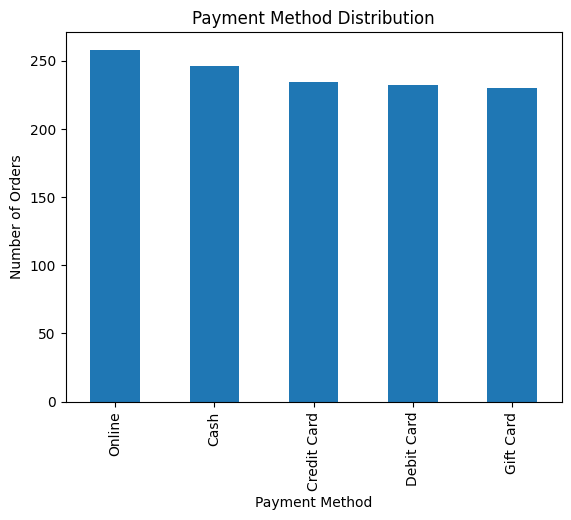

In [33]:
import matplotlib.pyplot as plt

df["PaymentMethod"].value_counts().plot(kind="bar")

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.show()